In [13]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import cmocean.cm as cm

In [14]:
# File paths
bc_file = "/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/CanWWTP_20260715.nc"

us_file = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc"

iona_file = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc"

outfile = "/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_SalishSea.nc"

In [15]:
# Read files
ds = xr.open_dataset(bc_file)

ds_us = xr.open_dataset(us_file)

ds_us = ds_us.assign_coords(
    time_counter=ds_us.time_counter-1
)

ds_iona = xr.open_dataset(iona_file)

In [16]:
# Merge US files with BC files
common_variables = [
    "flux",
    "temperature",
    "NO3",
    "NH3",
    "oxygen",
    "alkalinity",
    "DIC",
    "PON",
    "DON",
]

mask = ds_us["flux"] > 0

for var in common_variables:

    ds[var] = xr.where(
        mask,
        ds_us[var],
        ds[var],
    )
# Insert Iona data into the BC file
jj, ii = np.where(ds_iona["flux"][0] > 0)

for j, i in zip(jj, ii):
    print(f"Iona: ({j}, {i})")

    for var in ds_iona.data_vars:

        if "time_counter" in ds_iona[var].dims:

            ds[var][:, j, i] = ds_iona[var][:, j, i]

    ds["alkalinity"][:, j, i] *= 2

Iona: (446, 304)
Iona: (446, 305)
Iona: (447, 304)
Iona: (447, 305)


#### Update Metadata

In [17]:
ds.attrs["title"] = (
    "Combined Salish Sea Wastewater Climatology"
)

ds.attrs["summary"] = (
    "Monthly climatology from Washington Ecology, "
    "British Columbia WWTP reports and Iona."
)

ds.attrs["creator_name"] = "Abdoul Tall"

ds.attrs["creator_email"] = "atall@eoas.ubc.ca"

ds.attrs["institution"] = "University of British Columbia"

ds.attrs["institution_fullname"] = "Earth, Ocean and Atmospheric Sciences, University of British Columbia, Vancouver, BC, Canada"

ds.attrs["history"] = (
    f"[{pd.Timestamp.now().strftime('%Y-%m-%d')}] Combined Canadian, US and Iona WWTP climatologies."
)

### Save

In [18]:
ds.to_netcdf(outfile)

print()
print("Saved")
print(outfile)


Saved
/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_SalishSea.nc


#### Plots

/tmp/ipykernel_758264/741282446.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")


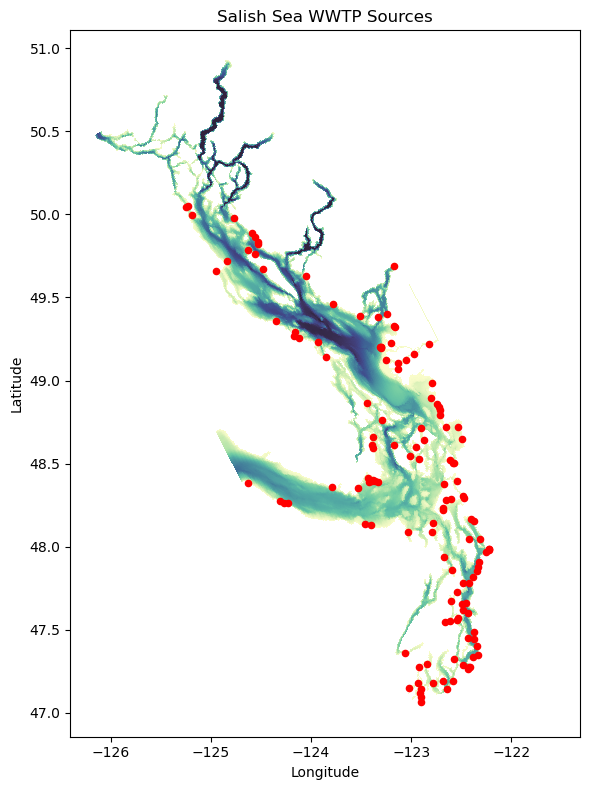

In [19]:
bathy = xr.open_dataset("/ocean/atall/MOAD/grid/bathymetry_202605.nc")
bathy_data = bathy["Bathymetry"]
lon_grid = bathy["nav_lon"]
lat_grid = bathy["nav_lat"]

flux = ds["flux"][0].values

j, i = np.where(flux > 0)

plt.figure(figsize=(6,8))

mesh = plt.pcolormesh(lon_grid,lat_grid,bathy_data,cmap=cm.deep,vmin=0,vmax=450,shading="auto")

plt.scatter(
    ds.nav_lon.values[j,i],
    ds.nav_lat.values[j,i],
    s=20,
    c="red",
)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Salish Sea WWTP Sources")

plt.tight_layout()

#plt.savefig("WWTP_locations.png",dpi=300)

plt.show()

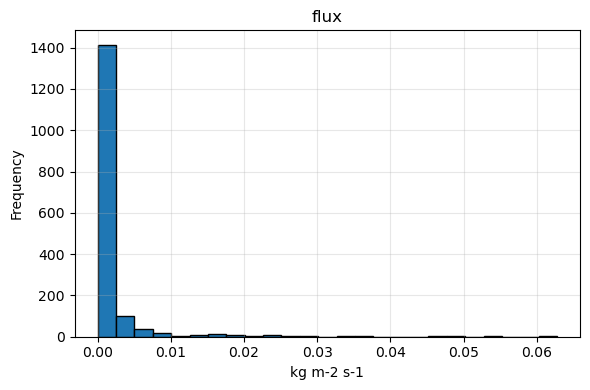

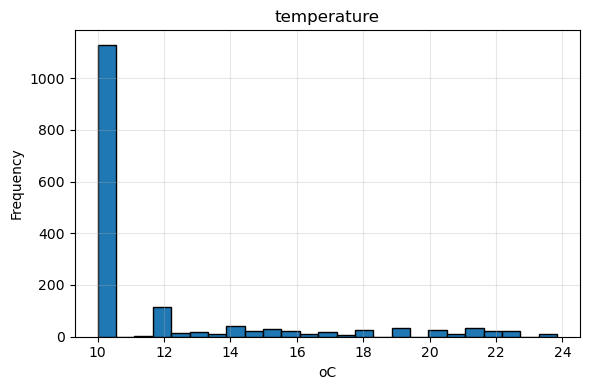

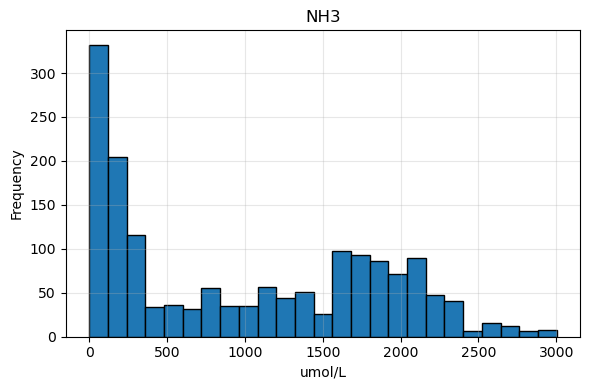

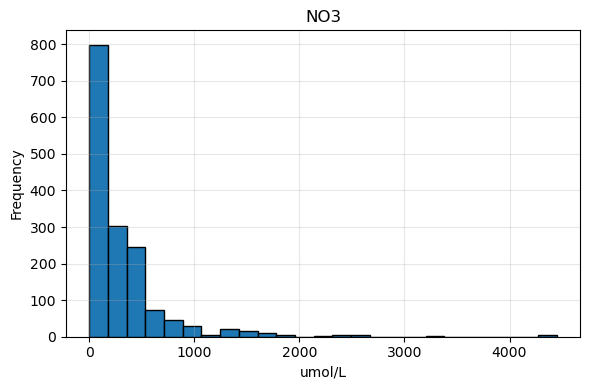

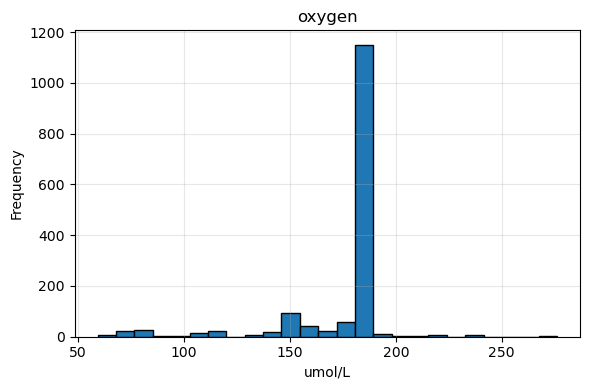

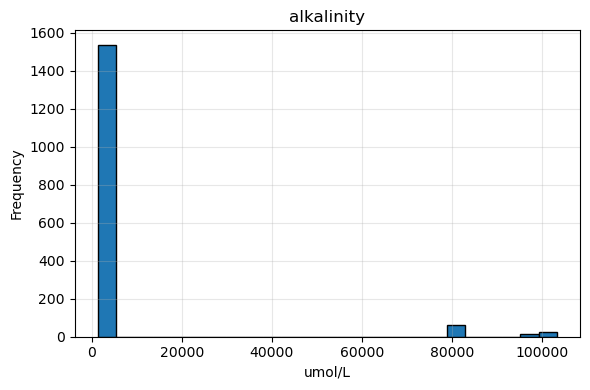

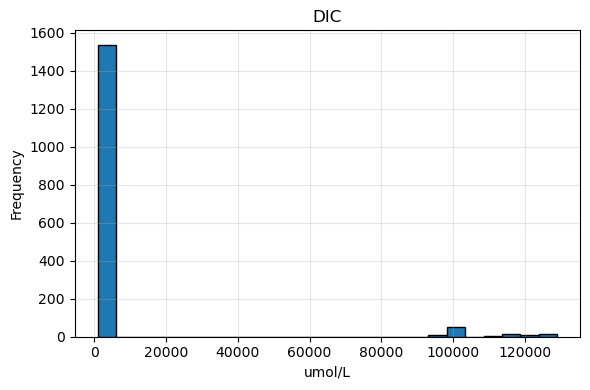

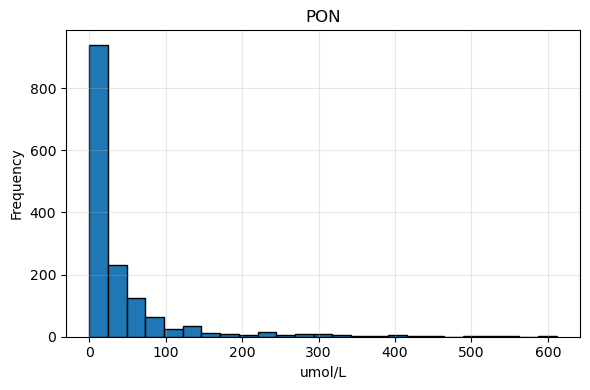

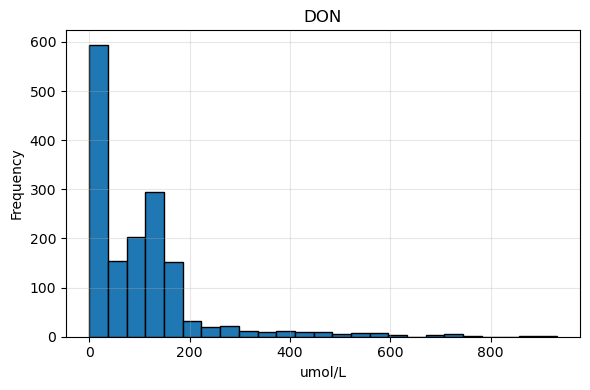

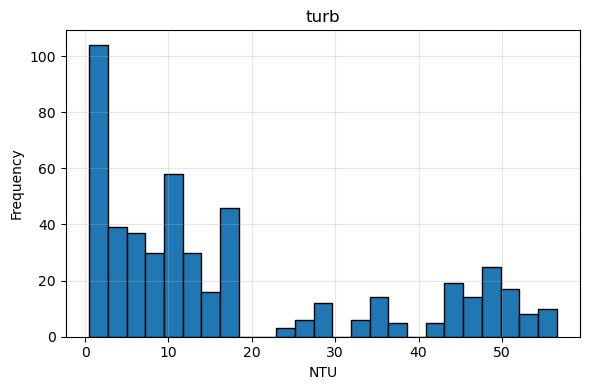

In [20]:

variables=[

    "flux",
    "temperature",
    "NH3",
    "NO3",
    "oxygen",
    "alkalinity",
    "DIC",
    "PON",
    "DON",
    "turb",

]

for var in variables:

    x = ds[var].values

    x = x[np.isfinite(x)]

    x = x[x>0]

    plt.figure(figsize=(6,4))

    plt.hist(
        x,
        bins=25,
        edgecolor="black",
    )

    plt.xlabel(
        ds[var].attrs.get("units","")
    )

    plt.ylabel("Frequency")

    plt.title(var)

    plt.grid(alpha=.3)

    plt.tight_layout()

    #plt.savefig(f"{var}_histogram.png",dpi=300)

    plt.show()

####

In [21]:
# Remove Canadian WWTPs from UW file

mask_can = np.zeros((ds_us.sizes["y"], ds_us.sizes["x"]),dtype=bool)

mask_can[380:500,200:398] = True # Identified from the map plot (Dishika plots)

mask_can[275:400,150:225] = True # Identified from the map plot (Dishika plots)

# Keep only discharge cells
mask_can &= (ds_us["flux"].max("time_counter").values > 0)

print(f"Removing {mask_can.sum()} Canadian discharge cells from UW file")

ds_us_only = ds_us.copy(deep=True)

for var in common_variables:

    data = ds_us_only[var].values

    data[:, mask_can] = 0

    ds_us_only[var].values[:] = data

Removing 9 Canadian discharge cells from UW file


In [22]:
extra_variables = [

    var for var in ds.data_vars

    if var not in ds_us_only.data_vars

    and "time_counter" in ds[var].dims

]

print("Adding missing variables:")
print(extra_variables)

for var in extra_variables:

    ds_us_only[var] = xr.zeros_like(ds[var])


Adding missing variables:
['dSi', 'diatoms', 'nanoflagellates', 'Z1', 'bSi', 'turb']


In [23]:
# Create Canada-only file

ds_can = ds.copy(deep=True)

# US discharge cells after Canadian sources were removed
mask_us = ds_us_only["flux"].max("time_counter").values > 0

print(f"Removing {mask_us.sum()} US discharge cells from Salish Sea file")

all_variables = [

    var for var in ds_can.data_vars

    if "time_counter" in ds_can[var].dims

]

for var in all_variables:

    data = ds_can[var].values

    data[:, mask_us] = 0

    ds_can[var].values[:] = data

Removing 85 US discharge cells from Salish Sea file


In [24]:
# Save files

ds_us_only.to_netcdf("/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_US.nc")

ds_can.to_netcdf("/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_Canada.nc")

print("Saved WWTP_US.nc")
print("Saved WWTP_Canada.nc")

Saved WWTP_US.nc
Saved WWTP_Canada.nc


In [27]:
print("Active discharge cells:")
print("All     :", np.sum(ds["flux"].max("time_counter").values > 0))
print("US      :", np.sum(ds_us_only["flux"].max("time_counter").values > 0))
print("Canada  :", np.sum(ds_can["flux"].max("time_counter").values > 0))

Active discharge cells:
All     : 136
US      : 85
Canada  : 51


In [31]:
# Create a freshwater-only file
ds_fw = ds.copy()

for var in ds_fw.data_vars:
    
    if var in ["flux", "temperature"]:
        continue

    ds_fw[var].values[:] = 0

ds_fw.to_netcdf("/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_FreshwaterOnly.nc")

In [30]:
# Create a file with no nutrients
nutrients = [
    "NH3",
    "NO3",
    "dSi",
    "PON",
    "DON",
    "bSi",
    "diatoms",
    "nanoflagellates",
    "Z1",
]

ds_nonutrient = ds.copy()

for var in nutrients:

    if var in ds_nonutrient:

        ds_nonutrient[var].values[:] = 0

ds_nonutrient.to_netcdf("/ocean/atall/MOAD/analysis-abdoul/notebooks/wastewater/CanWWTP/data/output/WWTP_NoNutrients.nc")